In [74]:
# import external modules
import numpy, os

# Add Exasim to Python search path
cdir = os.getcwd(); ii = cdir.find("Exasim")
exec(open(cdir[0:(ii+6)] + "/install/setpath.py").read())

# import internal modules
import Preprocessing, Postprocessing, Gencode, Mesh
import netCDF4
import Utilities, PlotUtilities

==> Exasim frontends ...



In [86]:
# Create pde object and mesh object
pde,mesh = Preprocessing.initializeexasim()


# Define a PDE model: governing equations and boundary conditions
pde['model'] = "ModelD";       # ModelC, ModelD, ModelW
pde['modelfile'] = "pdemodel2"; # name of a file defining the PDE model
pde['hybrid'] = 1;          # 0 -> LDG, 1 -> HDG

# Choose computing platform and set number of processors
pde['platform'] = "gpu"
pde['mpiprocs'] = 8
pde['cpucompiler']  = "CC"
pde['mpicompiler'] = "CC"
pde['gpucompiler'] = cdir[0:(ii+6)] + "/kokkos/bin/nvcc_wrapper" # e.g. /path_to_kokkos/bin/nvcc_wrapper

# Set discretization parameters, physical parameters, and solver parameters
pde['nd'] = 3
pde['porder'] = 2;         # polynomial degree
pde['pgauss'] = 2*pde['porder'] # number of Gauss points for quadrature
pde['tau'] = numpy.array([5.0]); # HDG stabilization parameter
pde['GMRESrestart'] = 249; # GMRES restart parameter
pde['GMRESortho'] = 1
pde['linearsolvertol'] = 1e-12; # linear solver tolerance
pde['linearsolveriter'] = 250
pde['preconditioner'] = 1
pde['ppdegree'] = 0; # degree of polynomial precontiditoning
pde['RBdim'] = 0; # reduced basis dimension for preconditioner
pde['NLtol'] = 1e-8; # nonlinear solver tolerance
pde['NLiter'] = 5; # number of nonlinear iterations
pde['matvectol'] = 1e-6; # matrix-vector product tolerance

flagGencode = True

# Physical parameters
dt0 = 5.0  # time step size in seconds
tf = 300  # final time in seconds
nsave = 1 # save every nsave time steps
nt = int(tf/dt0) # number of time steps

Re = 6378e3
hL = 100e3; hT = 600e3

gam = 5/3
mp = 1.67e-27
kB = 1.38e-23
e = 1.602e-19
g0 = 9.81*Re*Re/(Re + hL)**2
omega = 2*numpy.pi/86400

n0 = 1e12
T0 = 200.0
H0 = kB*T0/(mp*g0)
v0 = numpy.sqrt(gam*kB*T0/mp)
t0 = H0/v0
B0 = 7.94e15/(Re + hL)**3
E0 = B0*v0
kappa0 = 4.2e-7
nu0 = 6000
nu_eps = 5e-2

dampfac = 0

# Nondimensional parameters
R0 = (Re + hL)/H0
R1 = (Re + hT)/H0
Omega0 = 1/t0
Q0 = n0*kB*T0/t0
m_op = 16 # molar mass of O+
m_o2p = 32 # molar mass of O2+
m_np = 14 # molar mass of N+
m_n2p = 28 # molar mass of N2+
m_nop = 30 # molar mass of NO+
Ro = omega/Omega0 # Rossby number (inverse)
Kn = nu0/Omega0 # Knudsen number (inverse)
Omega = e*B0/(mp*Omega0) # ratio between gyro frequency and reference frequency
Pe = kappa0/(n0*kB*v0*H0) # Peclet number (inverse)

psi_op = 0 # upper boundary O+ number flux
psi_o2p = 0 # upper boundary O2+ number flux
psi_np = 0 # upper boundary N+ number flux
psi_n2p = 0 # upper boundary N2+ number flux
psi_nop = 0 # upper boundary NO+ number flux
qi = 0 # upper boundary ion heat flux
qe = 0 # upper boundary electron heat flux

# Nondimensional parameters
pde['physicsparam'] = numpy.array([gam, Ro, Kn, Omega, Pe, m_op, m_o2p, m_np, m_n2p, m_nop,
                                   psi_op, psi_o2p, psi_np, psi_n2p, psi_nop, qi, qe, dampfac,
                                   R0, R1, Re, H0])

# Time-stepping parameters
pde['torder'] = 2;          # time-stepping order of accuracy
pde['nstage'] = 2;          # time-stepping number of stages
pde['dt'] = (dt0/t0)*numpy.ones(nt);   # time step sizes
pde['soltime'] = numpy.arange(1,pde['dt'].size+1,nsave); # steps at which solution are collected
pde['visdt'] = 1.0; # visualization timestep size

# Mesh generation
hDiv = 18 #horizontal divisions
nDiv = 1 # number of grid elements per scale height
mesh['p'], mesh['t'], mesh['dgnodes'] = Mesh.cubesphere_scaleheight(pde['porder'], hDiv, nDiv, hL, hT, H0)
# mesh['p'], mesh['t'], mesh['dgnodes'] = Mesh.cubesphere(pde['porder'],R0,R1,15,10)
mesh['boundaryexpr'] = [
    lambda p: abs(p[0,:]**2 + p[1,:]**2 + p[2,:]**2 - R0**2) < 1e-6,
    lambda p: abs(p[0,:]**2 + p[1,:]**2 + p[2,:]**2 - R1**2) < 1e-6]
mesh['boundarycondition'] = numpy.array([1, 2]); # Set boundary condition for each boundary
npe, nd, ne = mesh['dgnodes'].shape

In [76]:
timeidx = 0
data = netCDF4.Dataset(filename='/glade/work/haonan/data.nc')
nalt = data.dimensions['alt'].size
nnode = data.dimensions['node'].size
nodeidx = data['nodeidx_out'][:].filled() - 1
altidx = data['altidx_out'][:].filled() - 1
op = data['OP'][:].filled()
o2p = data['O2P'][:].filled()
np = data['NP'][:].filled()
n2p = data['N2P'][:].filled()
nop = data['NOP'][:].filled()
v1 = data['V1'][:].filled()
v2 = data['V2'][:].filled()
v3 = data['V3'][:].filled()
ti = data['TI'][:].filled()
te = data['TE'][:].filled()
prod_op = data['PROD_OP'][:].filled()
prod_o2p = data['PROD_O2P'][:].filled()
prod_np = data['PROD_NP'][:].filled()
prod_n2p = data['PROD_N2P'][:].filled()
prod_nop = data['PROD_NOP'][:].filled()
loss_op = data['LOSS_OP'][:].filled()
loss_o2p = data['LOSS_O2P'][:].filled()
loss_np = data['LOSS_NP'][:].filled()
loss_n2p = data['LOSS_N2P'][:].filled()
loss_nop = data['LOSS_NOP'][:].filled()
nu_op = data['NU_OP'][:].filled()
nu_o2p = data['NU_O2P'][:].filled()
nu_np = data['NU_NP'][:].filled()
nu_n2p = data['NU_N2P'][:].filled()
nu_nop = data['NU_NOP'][:].filled()
E1 = data['E1'][:].filled()
E2 = data['E2'][:].filled()
E3 = data['E3'][:].filled()
heat_i = data['HEAT_I'][:].filled()
heat_e = data['HEAT_E'][:].filled()
qei = data['QEI'][:].filled()
qin = data['QIN'][:].filled()
qen = data['QEN'][:].filled()
kappa_i = data['KAPPA_I'][:].filled()
kappa_e = data['KAPPA_E'][:].filled()
tn = data['TN'][:].filled()
u1 = data['U1'][:].filled()
u2 = data['U2'][:].filled()
u3 = data['U3'][:].filled()
b1 = data['b1'][:].filled()
b2 = data['b2'][:].filled()
b3 = data['b3'][:].filled()
Bmag = data['B'][:].filled()
data.close()

eden = op + o2p + np + n2p + nop
nm = op*m_op + o2p*m_o2p + np*m_np + n2p*m_n2p + nop*m_nop
phi1 = nm*v1
phi2 = nm*v2
phi3 = nm*v3
pi = eden*ti
pe = eden*te

mesh['udg'] = numpy.zeros((npe,10,ne))
mesh['vdg'] = numpy.zeros((npe,46,ne))
for icell in range(ne):
    for inode in range(npe):
        k = altidx[inode, icell]
        n = nodeidx[inode, icell]

        # Initial conditions
        mesh['udg'][inode, 0, icell] = numpy.log(op[k, n])
        mesh['udg'][inode, 1, icell] = numpy.log(o2p[k, n])
        mesh['udg'][inode, 2, icell] = numpy.log(np[k, n])
        mesh['udg'][inode, 3, icell] = numpy.log(n2p[k, n])
        mesh['udg'][inode, 4, icell] = numpy.log(nop[k, n])
        mesh['udg'][inode, 5, icell] = v1[k, n]
        mesh['udg'][inode, 6, icell] = v2[k, n]
        mesh['udg'][inode, 7, icell] = v3[k, n]
        mesh['udg'][inode, 8, icell] = ti[k, n]
        mesh['udg'][inode, 9, icell] = te[k, n]

        # External fields
        # 0: prod_op, 1: prod_o2p, 2: prod_np, 3: prod_n2p, 4: prod_nop
        # 5: loss_op, 6: loss_o2p, 7: loss_np, 8: loss_n2p, 9: loss_nop
        # 10: nu_op, 11: nu_o2p, 12: nu_np, 13: nu_n2p, 14: nu_nop
        # 15: E1, 16: E2, 17: E3, 18: heat_i, 19: heat_e
        # 20: qei, 21: qin, 22: qen, 23: kappa_i, 24: kappa_e
        # 25: tn, 26: u1, 27: u2, 28: u3, 29: b1, 30: b2, 31: b3, 32: Bmag
        # 33: lnBx, 34: lnBy, 35: lnBz, 36: b.grad(lnB)
        # 37: b1x, 38: b1y, 39: b1z, 40: b2x, 41: b2y, 42: b2z, 43: b3x, 44: b3y, 45: b3z
        mesh['vdg'][inode, 0, icell] = prod_op[k, n]
        mesh['vdg'][inode, 1, icell] = prod_o2p[k, n]
        mesh['vdg'][inode, 2, icell] = prod_np[k, n]
        mesh['vdg'][inode, 3, icell] = prod_n2p[k, n]
        mesh['vdg'][inode, 4, icell] = prod_nop[k, n]
        mesh['vdg'][inode, 5, icell] = loss_op[k, n]
        mesh['vdg'][inode, 6, icell] = loss_o2p[k, n]
        mesh['vdg'][inode, 7, icell] = loss_np[k, n]
        mesh['vdg'][inode, 8, icell] = loss_n2p[k, n]
        mesh['vdg'][inode, 9, icell] = loss_nop[k, n]
        mesh['vdg'][inode, 10, icell] = nu_op[k, n]
        mesh['vdg'][inode, 11, icell] = nu_o2p[k, n]
        mesh['vdg'][inode, 12, icell] = nu_np[k, n]
        mesh['vdg'][inode, 13, icell] = nu_n2p[k, n]
        mesh['vdg'][inode, 14, icell] = nu_nop[k, n]
        mesh['vdg'][inode, 15, icell] = E1[k, n]
        mesh['vdg'][inode, 16, icell] = E2[k, n]
        mesh['vdg'][inode, 17, icell] = E3[k, n]
        mesh['vdg'][inode, 18, icell] = heat_i[k, n]
        mesh['vdg'][inode, 19, icell] = heat_e[k, n]
        mesh['vdg'][inode, 20, icell] = qei[k, n]
        mesh['vdg'][inode, 21, icell] = qin[k, n]
        mesh['vdg'][inode, 22, icell] = qen[k, n]
        mesh['vdg'][inode, 23, icell] = kappa_i[k, n]
        mesh['vdg'][inode, 24, icell] = kappa_e[k, n]
        mesh['vdg'][inode, 25, icell] = tn[k, n]
        mesh['vdg'][inode, 26, icell] = u1[k, n]
        mesh['vdg'][inode, 27, icell] = u2[k, n]
        mesh['vdg'][inode, 28, icell] = u3[k, n]
        mesh['vdg'][inode, 29, icell] = b1[k, n]
        mesh['vdg'][inode, 30, icell] = b2[k, n]
        mesh['vdg'][inode, 31, icell] = b3[k, n]
        mesh['vdg'][inode, 32, icell] = Bmag[k, n]

xpe,telem,xpf,tface,perm = Preprocessing.masternodes(pde['porder'],pde['nd'],1)
gpe, gwe = Preprocessing.gaussnodes(pde['pgauss'],pde['nd'],pde['elemtype'])
gpe = numpy.array(gpe,float)
shapeg = Preprocessing.mkshape(pde['porder'],xpe,gpe,1)

for d in range(0,pde['nd']+1):
    shapeg[:,:,d] = shapeg[:,:,d].transpose()

b1 = mesh['vdg'][:,29,:]
b2 = mesh['vdg'][:,30,:]
b3 = mesh['vdg'][:,31,:]

# calculate b.grad(lnB)
gradlnB = Preprocessing.gradu(shapeg[:,:,1:4], mesh['dgnodes'], numpy.log(mesh['vdg'][:,32,:]))
mesh['vdg'][:,33:36,:] = gradlnB
mesh['vdg'][:,36,:] = b1*gradlnB[:,0,:] + b2*gradlnB[:,1,:] + b3*gradlnB[:,2,:]
# calculate grad(b)
mesh['vdg'][:,37:40,:] = Preprocessing.gradu(shapeg[:,:,1:4], mesh['dgnodes'], b1)
mesh['vdg'][:,40:43,:] = Preprocessing.gradu(shapeg[:,:,1:4], mesh['dgnodes'], b2)
mesh['vdg'][:,43:46,:] = Preprocessing.gradu(shapeg[:,:,1:4], mesh['dgnodes'], b3)

In [49]:
op = numpy.exp(mesh['udg'][:,0,:]) 
o2p = numpy.exp(mesh['udg'][:,1,:]) 
np = numpy.exp(mesh['udg'][:,2,:]) 
n2p = numpy.exp(mesh['udg'][:,3,:]) 
nop = numpy.exp(mesh['udg'][:,4,:]) 
ne = nop + o2p + np + n2p + nop


ke00 = mesh['vdg'][:, 24, :]/1.6e-17

# smooth clip Te to be at most 3000
mesh['udg'][:,9,:] = 2500*numpy.tanh(mesh['udg'][:,9,:]/2500)

a1 = 7.5e5
a2 = 3.22e4
a3 = 1.1e-16
a4 = 5.7e-4
Q0 = ne*(a1/ke00-1)/(a2*mesh['udg'][:,9,:]**2)
no = Q0/(a3*(1+a4*mesh['udg'][:,9,:]))
# smooth clip no to be at least 1e3
# no = numpy.sqrt(no**2 + 1e10**2)

no = op*1e6

Q = 1.1e-16*(1+5.7e-4*mesh['udg'][:,8,:])*no
ke0 = 7.5e5/(1+3.22e4*mesh['udg'][:,8,:]**2*Q/ne)
ke = ke0*mesh['udg'][:,8,:]**2.5*1.6e-17

ki0 = 1.15e4*op/ne
ki = ki0*mesh['udg'][:,8,:]**2.5*1.6e-17

Text(0.5, 1.0, 'Altitude: 100.0 km')

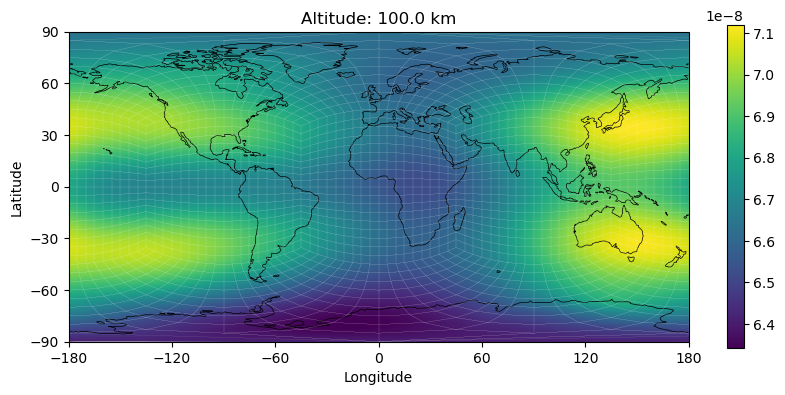

In [85]:
ilev = -0
quant = 1.15e4*1.6e-17*mesh['vdg'][:, 25, :]**2.5
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(mesh['dgnodes'],quant,pde,ilev)
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')

Text(0.5, 1.0, 'Altitude: 106.3 km')

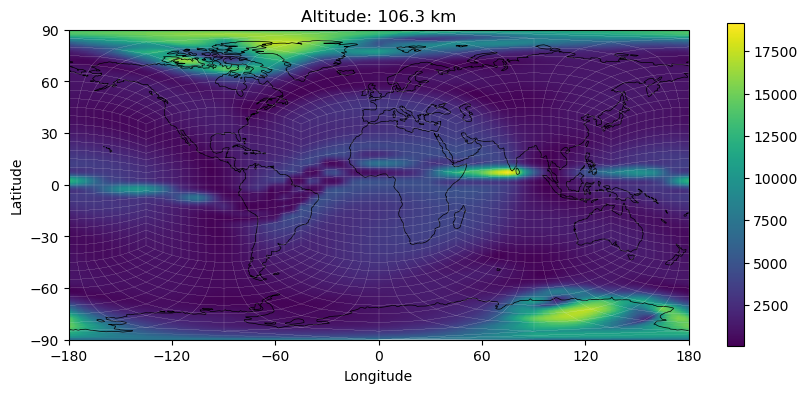

In [12]:
ilev = 2
# var = numpy.sqrt(mesh['vdg'][:,0,:]**2 + mesh['vdg'][:,1,:]**2 + mesh['vdg'][:,2,:]**2)
uimvi = numpy.sqrt((mesh['vdg'][:,12,:]-mesh['vdg'][:,15,:])**2 + (mesh['vdg'][:,13,:]-mesh['vdg'][:,16,:])**2 + (mesh['vdg'][:,14,:]-mesh['vdg'][:,17,:])**2)
var = piNu*mesh['vdg'][:,11,:]*(uimvi)
xcg2d, ucg2d, altitude, xgrid = PlotUtilities.getslice(mesh['dgnodes'],var,pde,ilev)
fig, ax = PlotUtilities.plotslice(xcg2d,ucg2d, xgrid, coastlines=True, coastcolor='k', coastlw=0.5, color='w', lw=0.05)
ax.set_title(f'Altitude: {(altitude*H0 - Re)/1000:.1f} km')